In [59]:
import sys
sys.path.append('../src/')

import numpy as np
import matplotlib.pyplot as plt
from simplex_bisection import *
from broyden import broyden_solver
from ensemble_kalman_inversion import EKI

%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
from functools import cache
class fun:
  '''
  Simple overdermined system with unique solution
  x=0.3, y=0.4
  '''
  def __init__(self, noise=0.0):
    self.calls = 0
    self.noise = noise
  def __call__(self, x, y):
    out = np.array([x+y-0.7, x-y+0.1, 2*x+y-1])
    out += self.noise * np.random.randn(*out.shape)
    return out
  @cache
  def lookup_table(self, _x):
    self.calls += 1
    x = np.array(_x)
    out = np.array([x[0]+x[1]-0.7, x[0]-x[1]+0.1, 2*x[0]+x[1]-1])
    out += self.noise * np.random.randn(*out.shape)
    return out
  def plot(self, x_range=(0,1), y_range=(0,1)):
    X, Y = np.meshgrid(np.linspace(*x_range,100), np.linspace(*y_range,100))
    f1, f2, f3 = self(X,Y)
    plt.contourf(X,Y,f1**2 + f2**2 + f3**2, levels=20, cmap='RdBu_r')
    plt.plot(0.3, 0.4, '*', label='True solution', markersize=20)
    plt.title(f'Number of function calls = {self.calls}')
fun()(0.3,0.4)

array([ 0.00000000e+00, -2.77555756e-17,  0.00000000e+00])

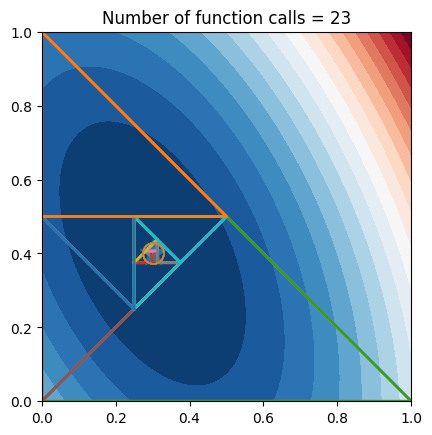

In [121]:
f = fun()
root, _ = SimplexBisection(f, dimension=2, max_depth=20, exploration=True, bisect_parent=True);
f.plot()
root.plot_all()

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from functools import cache

class himmelblau_fun:
    '''
    Vector-valued version of Himmelblau's function:
    f(x, y) = [x^2 + y - 11, x + y^2 - 7]
    Has four global minima:
      (3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)
    '''
    def __init__(self, noise=0.0, seed=0):
        self.noise = noise
        self.calls = 0
        self.rng = np.random.default_rng(seed)
        self.errors = []
        self.x = []
        self.dim_of_parameters = 2

    def __call__(self, _x):
        self.calls += 1
        x = np.array(_x)
        self.x.append(x)
        out = np.array([x[0]**2 + x[1] - 11., x[0] + x[1]**2 - 7.])
        out += self.noise * self.rng.normal(out.shape)
        self.errors.append(np.linalg.norm(x-np.array([-2.805, 3.131])))
        return out
    
    @cache
    def lookup_table(self, x):
        return self(x)

    def call(self, x, y):
        out = np.array([x**2 + y - 11., x + y**2 - 7.])
        out += self.noise * self.rng.normal(size=out.shape)
        return out
    
    def plot(self, x_range=(-6, 6), y_range=(-6, 6)):
        X, Y = np.meshgrid(np.linspace(*x_range, 400), np.linspace(*y_range, 400))
        f1, f2 = self.call(X, Y)
        Z = f1**2 + f2**2
        plt.contourf(X, Y, Z, levels=40, cmap='RdBu_r')
        # plot one of the known minima
        minima = [(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
        for i, (xm, ym) in enumerate(minima):
            plt.plot(xm, ym, '*', markersize=12)#, label=f'minimum {i+1}', markersize=12)
        plt.title(f'Himmelblau function ||f(x,y)||²\nFunction calls: {self.calls}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.colorbar(label='||f(x, y)||²')
        #plt.legend()

(-6.0, 6.0)

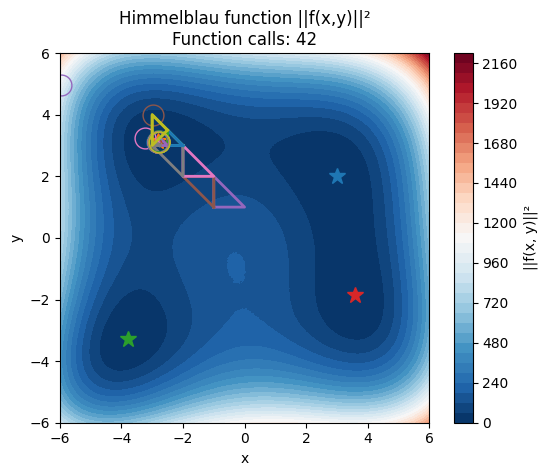

In [62]:
f_bisection = himmelblau_fun(noise=0.01, seed=5)
root = Simplex(dimension=2, vertices=[[-1,1],[0,1],[-1,2]])
root, _ = SimplexBisection(f_bisection, dimension=2, max_depth=10, exploration=True, root=root, bisect_parent=True, evaluate_best=True);
f_bisection.plot()
root.plot_all()
plt.xlim([-6,6])
plt.ylim([-6,6])

(-6.0, 6.0)

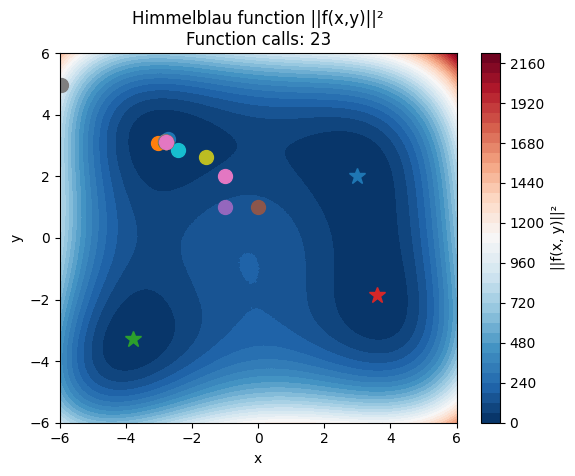

In [63]:
f_broyden = himmelblau_fun(noise=0.01, seed=5)
root, _ = broyden_solver(f_broyden, [-1,1], niters=20);
f_broyden.plot()
for x in f_broyden.x:
    plt.plot(x[0], x[1], marker='o', markersize=10)
plt.xlim([-6,6])
plt.ylim([-6,6])

(-6.0, 6.0)

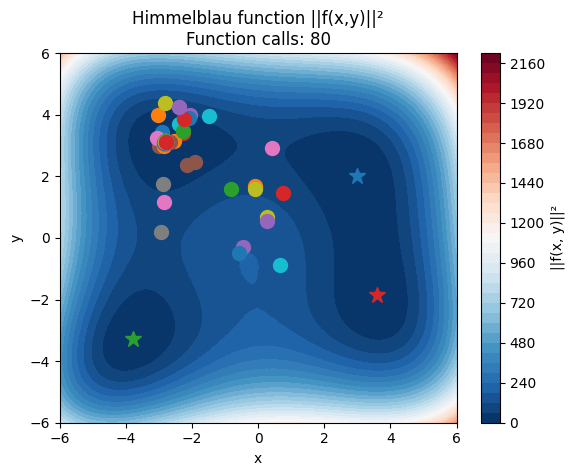

In [64]:
f_eki = himmelblau_fun(noise=0.01, seed=5)
root, stats = EKI(f_eki, niters=5, ens_size=15, uniform=True, low = [-3,-1], high=[1,3], noise=0.01, seed=0);
f_eki.plot()
for x in f_eki.x:
    plt.plot(x[0], x[1], marker='o', markersize=10)
plt.xlim([-6,6])
plt.ylim([-6,6])

In [66]:
f_eki_jl = himmelblau_fun(noise=0.01, seed=5)
root_jl, stats_jl = EKI(f_eki_jl, niters=5, ens_size=15, uniform=True, low = [-3,-1], high=[1,3], noise=0.01, y=np.zeros(2), seed=0, julia_backend=True);
print(root_jl - root)

[0. 0.]


(-6.0, 6.0)

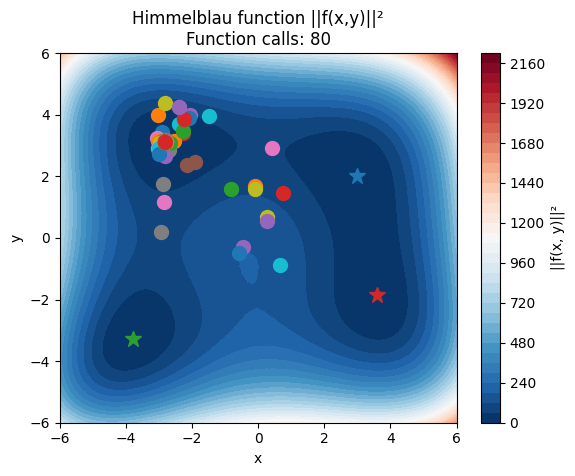

In [70]:
f_eki_acc = himmelblau_fun(noise=0.01, seed=5)
root_acc, stats_acc = EKI(f_eki_acc, niters=5, ens_size=15, uniform=True, 
                        low = [-3,-1], high=[1,3], noise=0.01, y=np.zeros(2), seed=0, 
                        julia_backend=True,
                        accelerator = "NesterovAccelerator()");
f_eki_acc.plot()
for x in f_eki_acc.x:
    plt.plot(x[0], x[1], marker='o', markersize=10)
plt.xlim([-6,6])
plt.ylim([-6,6])

(-6.0, 6.0)

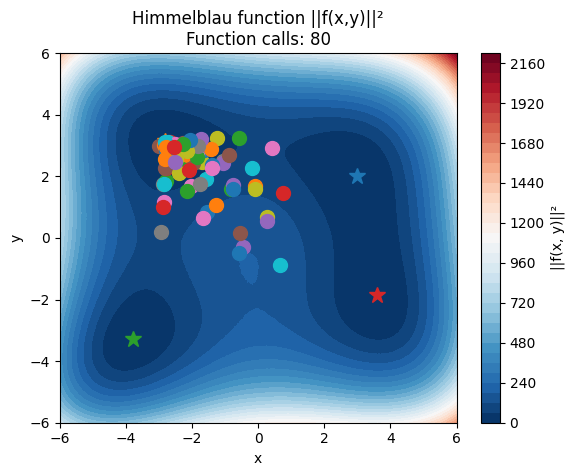

In [73]:
f_eki_msf = himmelblau_fun(noise=0.01, seed=5)
root_msf, stats_msf = EKI(f_eki_msf, niters=5, ens_size=15, uniform=True, 
                        low = [-3,-1], high=[1,3], noise=0.01, y=np.zeros(2), seed=0, 
                        julia_backend=True,
                        scheduler = "DataMisfitController(terminate_at = 1)");
f_eki_msf.plot()
for x in f_eki_msf.x:
    plt.plot(x[0], x[1], marker='o', markersize=10)
plt.xlim([-6,6])
plt.ylim([-6,6])

(-6.0, 6.0)

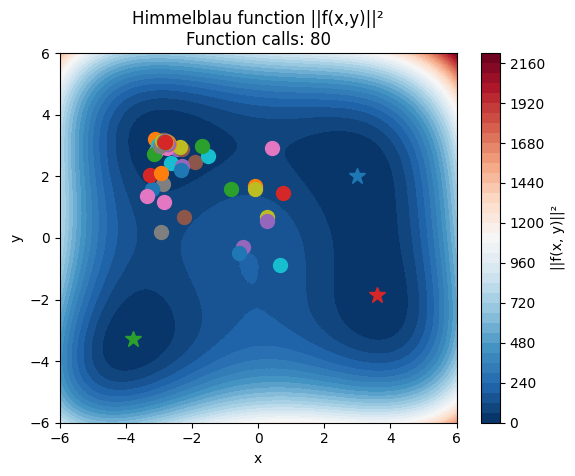

In [83]:
f_eki_loc = himmelblau_fun(noise=0.01, seed=5)
root_loc, stats_loc = EKI(f_eki_loc, niters=5, ens_size=15, uniform=True, 
                        low = [-3,-1], high=[1,3], noise=0.01, y=np.zeros(2), seed=0, 
                        julia_backend=True,
                        localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()");
f_eki_loc.plot()
for x in f_eki_loc.x:
    plt.plot(x[0], x[1], marker='o', markersize=10)
plt.xlim([-6,6])
plt.ylim([-6,6])

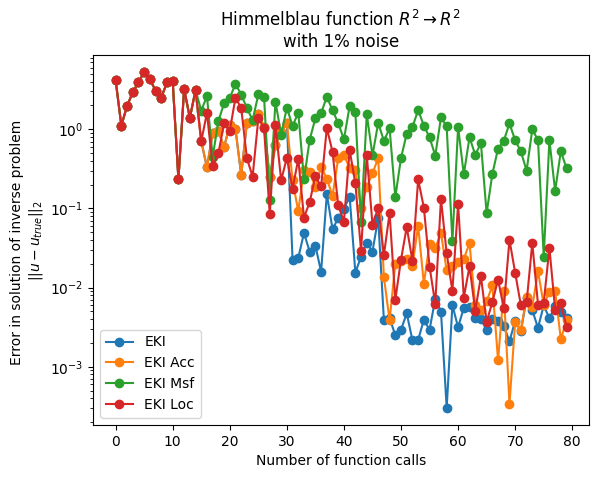

In [86]:
#plt.plot(f_bisection.errors, label='SimplexBisection', marker='o')
#plt.plot(f_broyden.errors, label='Broyden',marker='o')
plt.plot(f_eki.errors, label='EKI',marker='o')
plt.plot(f_eki_acc.errors, label='EKI Acc',marker='o')
plt.plot(f_eki_msf.errors, label='EKI Msf',marker='o')
plt.plot(f_eki_loc.errors, label='EKI Loc',marker='o')
plt.yscale('log')
plt.xlabel('Number of function calls')
plt.ylabel('Error in solution of inverse problem \n$||u-u_{true}||_2$')
plt.title('Himmelblau function $R^2 \\to R^2$ \nwith 1% noise')
plt.legend()

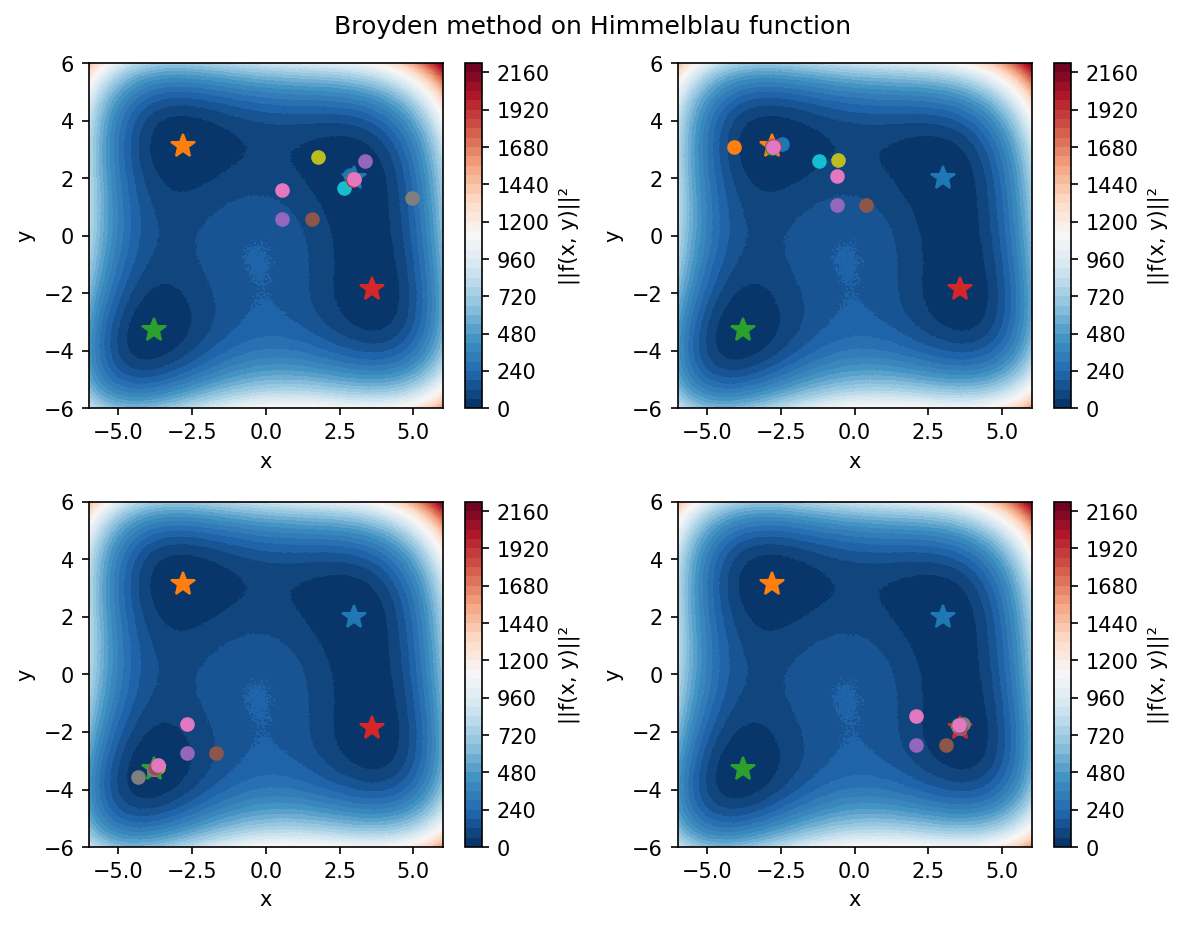

In [187]:
plt.figure(figsize=(8,6),dpi=150)
for iteration in range(4):
    x_init = 2 * np.random.randn(2)
    plt.subplot(2,2,iteration+1)
    f_broyden = himmelblau_fun(noise=0.1)
    root, _ = broyden_solver(f_broyden, x_init, niters=10);
    f_broyden.plot()
    for x in f_broyden.x:
        plt.plot(x[0], x[1], marker='o', markersize=6)
    plt.xlim([-6,6])
    plt.ylim([-6,6])
    plt.title('')
plt.tight_layout()
plt.suptitle('Broyden method on Himmelblau function', y=1.02)
plt.savefig('broyden_method.png', dpi=200, bbox_inches='tight')

# Rosenbrock function

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from functools import cache

class Rosenbrock:
    '''
    Vector-valued version of Himmelblau's function:
    f(x,y)=[(a-x), b(y-x^{2})]
    with a=1, b=100
    Has a global minimum:
    (1,1)
    '''
    def __init__(self, noise=0.0, seed=0, a=np.sqrt(7/5), b=1):
        self.noise = noise
        self.calls = 0
        self.rng = np.random.default_rng(seed)
        self.errors = []
        self.x = []
        self.dim_of_parameters = 2
        self.a = a
        self.b = b

    def __call__(self, _x):
        self.calls += 1
        x = np.array(_x)
        self.x.append(x)
        out = np.array([self.a - x[0], self.b * (x[1] - x[0]**2)])
        out += self.noise * self.rng.normal(size=out.shape)
        self.errors.append(np.linalg.norm(x-np.array([self.a,self.a**2])))
        return out
    
    @cache
    def lookup_table(self, x):
        return self(x)

    def call(self, x, y):
        out = np.array([self.a - x, self.b * (y - x**2)])
        out += self.noise * self.rng.normal(size=out.shape)
        return out
    
    def plot(self, x_range=(-6, 6), y_range=(-6, 6)):
        X, Y = np.meshgrid(np.linspace(*x_range, 400), np.linspace(*y_range, 400))
        f1, f2 = self.call(X, Y)
        Z = f1**2 + f2**2
        plt.contourf(X, Y, np.log10(Z), levels=20, cmap='viridis', vmin=-4, vmax=3)
        # plot one of the known minima
        plt.plot(self.a,self.a**2,marker='*', markersize=30, ls='')
        plt.title(f'Rosenbrock function ||f(x,y)||²\nFunction calls: {self.calls}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.colorbar(label='log10 ||f(x, y)||²')
        #plt.legend()

Text(0.5, 1.0, 'SimplexBisection')

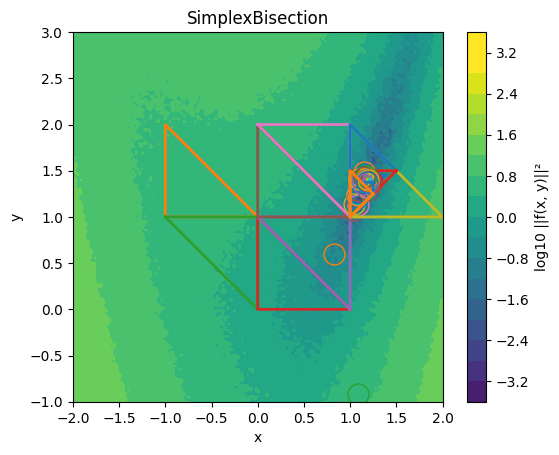

In [177]:
f_bisection = Rosenbrock(noise=0.1, seed=7)
root = Simplex(dimension=2, vertices=[[-1.,1],[0,1],[-1,2]])
root, _ = SimplexBisection(f_bisection, dimension=2, max_depth=10, root=root, exploration=True, bisect_parent=True, evaluate_best=True);
f_bisection.plot()
root.plot_all()
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('SimplexBisection')

Text(0.5, 1.0, 'Broyden')

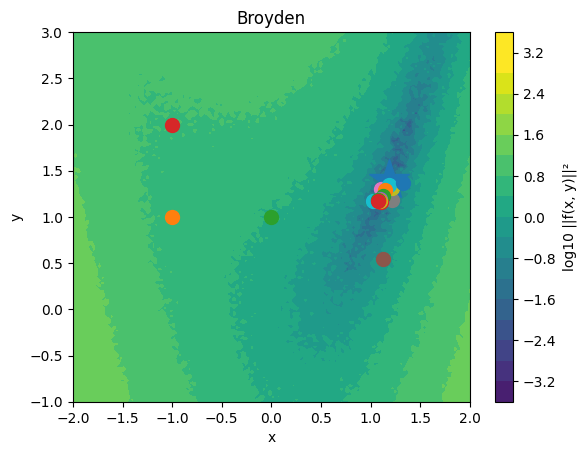

In [178]:
f_broyden = Rosenbrock(noise=0.1, seed=7)
broyden_solver(f_broyden, [-1,1], niters=20);
f_broyden.plot()
for x in f_broyden.x:
    plt.plot(x[0], x[1], marker='o', markersize=10)
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('Broyden')

Text(0.5, 1.0, 'EKI')

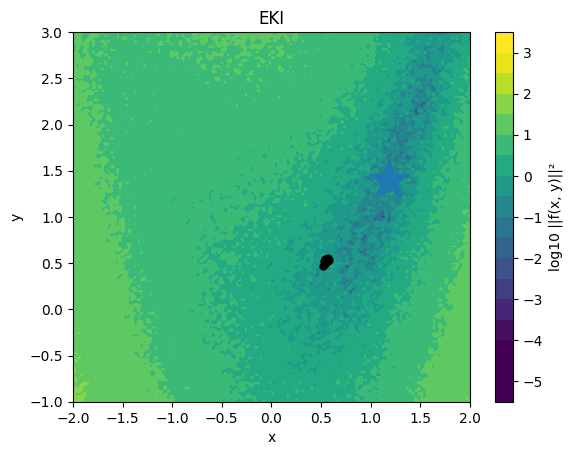

In [114]:
f_eki = Rosenbrock(noise=0.3, seed=7)
_, stats = EKI(f_eki, niters=20, ens_size=10, noise=0.3, uniform=True, low=[-1,1], high=[0,2], seed=0);
f_eki.plot()
for x in stats['x_ens'][-1].T:
    plt.plot(x[0], x[1], marker='o', markersize=5, color='k')
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('EKI')

Text(0.5, 1.0, 'EKI RL')

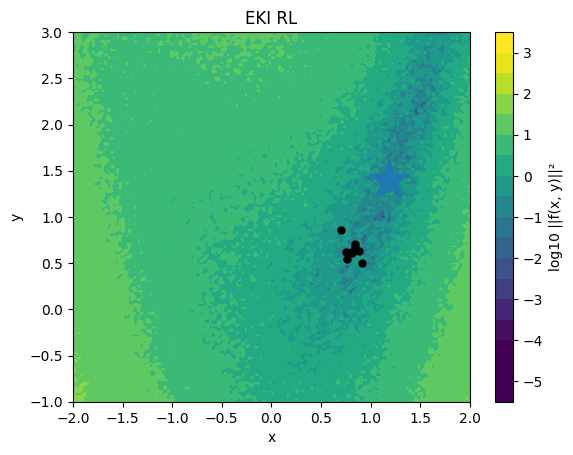

In [115]:
f_eki_rl = Rosenbrock(noise=0.3, seed=7)
_, stats = EKI(f_eki_rl, niters=20, ens_size=10, noise=0.3, uniform=True, low=[-1,1], high=[0,2], randomized_likelihood=True, seed=0);
f_eki_rl.plot()
#for x in f_eki.x:
for x in stats['x_ens'][-1].T:
    plt.plot(x[0], x[1], marker='o', markersize=5, color='k')
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('EKI RL')

Text(0.5, 1.0, 'EKI Acc')

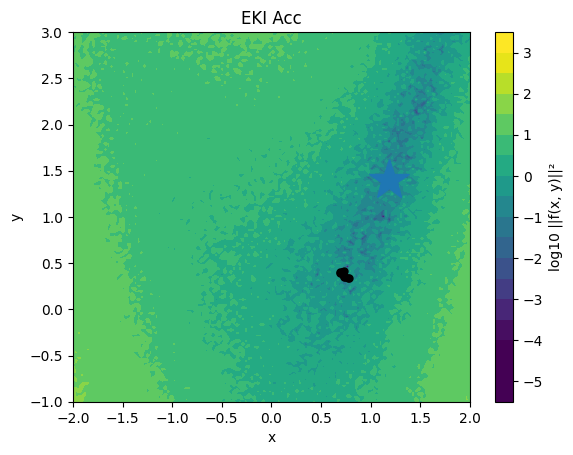

In [116]:
f_eki_acc = Rosenbrock(noise=0.3, seed=7)
_, stats = EKI(f_eki_acc, niters=20, ens_size=10, noise=0.3, uniform=True, low=[-1,1], high=[0,2],
               y = np.zeros(2), seed=0,
               julia_backend=True,
               accelerator = "NesterovAccelerator()"
              );
f_eki_acc.plot()
for x in stats['x_ens'][-1].T:
    plt.plot(x[0], x[1], marker='o', markersize=5, color='k')
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('EKI Acc')

Text(0.5, 1.0, 'EKI Loc')

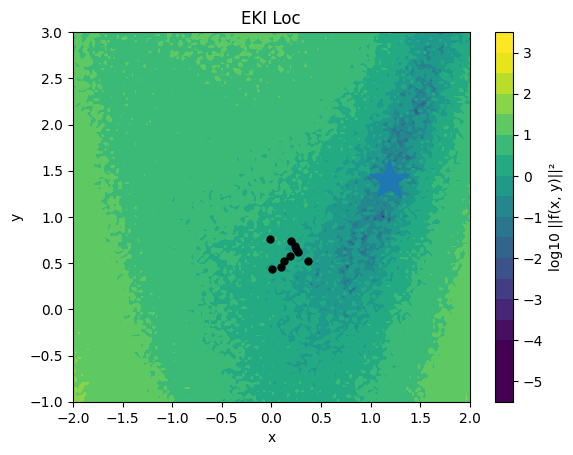

In [117]:
f_eki_loc = Rosenbrock(noise=0.3, seed=7)
_, stats = EKI(f_eki_loc, niters=20, ens_size=10, noise=0.3, uniform=True, low=[-1,1], high=[0,2],
               y = np.zeros(2), seed=0,
               julia_backend=True,
               localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()"
              );
f_eki_loc.plot()
for x in stats['x_ens'][-1].T:
    plt.plot(x[0], x[1], marker='o', markersize=5, color='k')
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('EKI Loc')

Text(0.5, 1.0, 'EKI Msf')

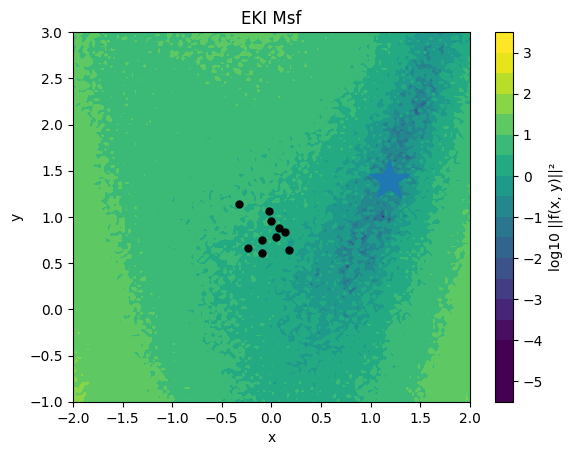

In [118]:
f_eki_msf = Rosenbrock(noise=0.3, seed=7)
_, stats = EKI(f_eki_msf, niters=20, ens_size=10, noise=0.3, uniform=True, low=[-1,1], high=[0,2],
               y = np.zeros(2), seed=0,
               julia_backend=True,
               scheduler = "DataMisfitController(terminate_at = 1)"
              );
f_eki_msf.plot()
for x in stats['x_ens'][-1].T:
    plt.plot(x[0], x[1], marker='o', markersize=5, color='k')
plt.xlim([-2,2])
plt.ylim([-1,3])
plt.title('EKI Msf')

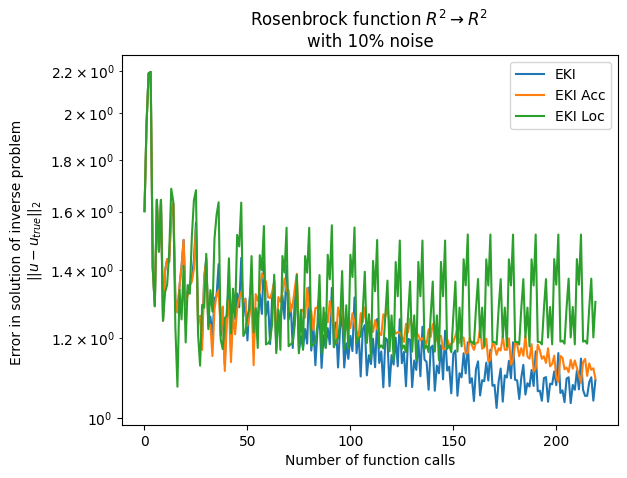

In [120]:
#plt.plot(f_bisection.errors, label='SimplexBisection')
#plt.plot(f_broyden.errors, label='Broyden')
plt.plot(f_eki.errors, label='EKI')
#plt.plot(f_eki_rl.errors, label='EKI RL')

plt.plot(f_eki_acc.errors, label='EKI Acc')
plt.plot(f_eki_loc.errors, label='EKI Loc')
#plt.plot(f_eki_msf.errors, label='EKI Msf')


plt.yscale('log')
plt.xlabel('Number of function calls')
plt.ylabel('Error in solution of inverse problem \n$||u-u_{true}||_2$')
plt.title('Rosenbrock function $R^2 \\to R^2$ \nwith 10% noise')
plt.legend()

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from functools import cache

class RosenbrockND:
    '''
    Multi-dimensional version of Rosenbrock function
    For N input variables
    there are 2*N-2 equations to solve

    x2-x1**2 = 0
    x3-x2**2 = 0
    ...
    x_N-x_{N-1}**2 = 0

    1 - x1 = 0
    1 - x2 = 0
    ...
    1-x_{N-1} = 0
    
    '''
    def __init__(self, noise=0.0, seed=0, N=7):
        self.noise = noise
        self.calls = 0
        self.rng = np.random.default_rng(seed)
        self.errors = []
        self.errors_local = []
        self.x = []
        self.dim_of_parameters = N

    def __call__(self, _x):
        self.calls += 1
        x = np.array(_x)
        self.x.append(x)
        
        out = np.hstack([x[1:] - x[:-1]**2, 1-x[:-1]])
        out += self.noise * self.rng.normal(size=out.shape)
        self.errors.append(np.linalg.norm(x-1))
        x_local = np.ones(self.dim_of_parameters)
        x_local[0] = -1
        self.errors_local.append(np.linalg.norm(x-x_local))
        return out
    
    @cache
    def lookup_table(self, x):
        return self(x)

RosenbrockND(N=100)(np.ones(100))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [168]:
dimension = 20
f_bisection = RosenbrockND(noise=0.4, seed=14, N=dimension)
root = Simplex(dimension=dimension, vertices=np.vstack([np.zeros(dimension),np.eye(dimension)])+np.pi/4)
root, _ = SimplexBisection(f_bisection, max_depth=10, root=root, exploration=True, bisect_parent=True, evaluate_best=True);

In [169]:
f_broyden = RosenbrockND(noise=0.4, seed=14, N=dimension)
broyden_solver(f_broyden, np.random.rand(dimension)+0.5, niters=100);

In [351]:
f_eki = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki = EKI(f_eki, niters=15, ens_size=60, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0);

In [272]:
f_eki_30 = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_30 = EKI(f_eki_30, niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0);

In [270]:
f_eki_rl = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_rl = EKI(f_eki_rl, niters=30, ens_size=300, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, randomized_likelihood=True, seed=0);

In [289]:
f_eki_acc = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_acc = EKI(f_eki_acc, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   accelerator = "NesterovAccelerator()");

In [292]:
f_eki_loc = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_loc = EKI(f_eki_loc, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()");

In [293]:
f_eki_msf = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_msf = EKI(f_eki_msf, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   scheduler = "DataMisfitController(terminate_at = 1)");

In [294]:
f_eki_all = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_all = EKI(f_eki_all, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   scheduler = "DataMisfitController(terminate_at = 1)",
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()",
   accelerator = "NesterovAccelerator()");

In [295]:
f_eki_msf_loc = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_msf_loc = EKI(f_eki_msf_loc, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   scheduler = "DataMisfitController(terminate_at = 1)",
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()");

In [296]:
f_eki_msf_acc = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_msf_acc = EKI(f_eki_msf_acc, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   scheduler = "DataMisfitController(terminate_at = 1)",
   accelerator = "NesterovAccelerator()");

In [297]:
f_eki_loc_acc = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_loc_acc = EKI(f_eki_loc_acc, y= np.zeros(dimension*2-2), niters=30, ens_size=30, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()",
   accelerator = "NesterovAccelerator()");

In [365]:
f_eki_loc_acc_60 = RosenbrockND(noise=0.4, seed=14, N=dimension)
_, stats_eki_loc_acc_60 = EKI(f_eki_loc_acc_60, y= np.zeros(dimension*2-2), niters=15, ens_size=60, noise=0.4, uniform=True, low=np.zeros(dimension)+0.5, high=np.ones(dimension)+0.5, seed=0,
   julia_backend=True,
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()",
   accelerator = "NesterovAccelerator()");

(0.0, 0.24799947397340447)

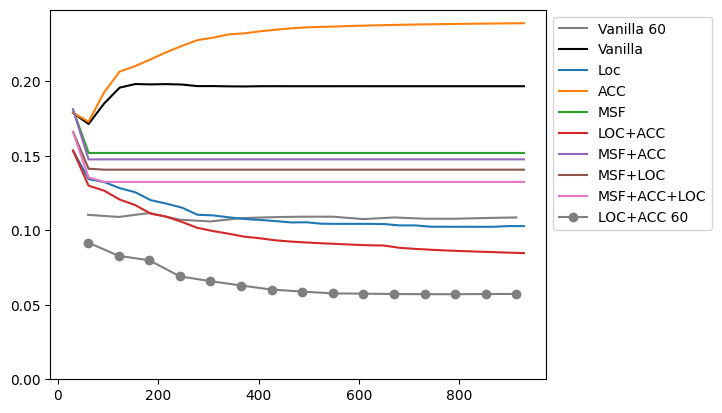

In [378]:
l = len(f_eki_loc_acc.errors)
l_60 = len(f_eki.errors)
idx = np.arange(30,l,31)
idx_60 = np.arange(60,l_60,61)
plt.plot(idx_60, f_eki.errors[60:None:61], color='gray', label='Vanilla 60')
plt.plot(idx, f_eki_30.errors[30:l:31], color='k', label='Vanilla')
plt.plot(idx, f_eki_loc.errors[30:l:31], label='Loc')
plt.plot(idx, f_eki_acc.errors[30:l:31], label='ACC')
plt.plot(idx, f_eki_msf.errors[30:l:31], label='MSF')
plt.plot(idx, f_eki_loc_acc.errors[30:l:31], label='LOC+ACC')
plt.plot(idx, f_eki_msf_acc.errors[30:l:31], label='MSF+ACC')
plt.plot(idx, f_eki_msf_loc.errors[30:l:31], label='MSF+LOC')
plt.plot(idx, f_eki_all.errors[30:l:31], label='MSF+ACC+LOC')

plt.plot(idx_60, f_eki_loc_acc_60.errors[60:None:61], label='LOC+ACC 60', marker='o')
#plt.yscale('log')
plt.legend(bbox_to_anchor=(1,1))
#plt.xscale('log')
plt.ylim([0,None])

To sum up,
* Data misfit controller effectively does not move the points after the initial iteration, and all implementations with it have no updates aftre the first iteration.
* On the other hand, data misfit shows that convergence is achieved and further iteration is not required.
* Accelerator alone does not work well with a small ensemble. But when combined with misfit controller or localization, works fine.
* The only option which allows to make further useful updates is the Localization.
* Accelerator combined wuth Localization is the best method for a given ensemble size as it allows to keep improving the prediction.
* However, a somewhat better skill can be achieved by simply doubling the ensemble size and using the Vanilla EKI.
* Even better is to increase the ensemble size and to use a combination of acceleration and localizer.
* Localizer or data-misfit drastically change the distribution of particles. Instead of early ensemble collapse, they keep the density more spread around the true solution.

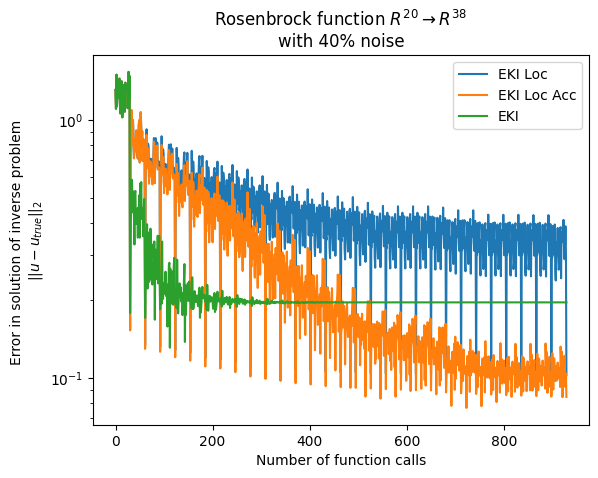

In [376]:
#plt.plot(f_bisection.errors, label='SimplexBisection')
#plt.plot(f_broyden.errors, label='Broyden')
plt.plot(f_eki_loc.errors, label='EKI Loc')
#plt.plot(f_eki_rl.errors, label='EKI RL')
#plt.plot(f_eki_acc.errors, label='EKI Acc')
#plt.plot(f_eki_msf.errors, label='EKI Msf')
#plt.plot(f_eki_msf_loc.errors, label='EKI Msf Loc')
#plt.plot(f_eki_msf_acc.errors, label='EKI Msf Acc')
plt.plot(f_eki_loc_acc.errors, label='EKI Loc Acc')

plt.plot(f_eki_30.errors, label='EKI')
plt.yscale('log')
plt.xlabel('Number of function calls')
plt.ylabel('Error in solution of inverse problem \n$||u-u_{true}||_2$')
plt.title('Rosenbrock function $R^{20} \\to R^{38}$ \nwith 40% noise')
plt.legend(bbox_to_anchor=(1,1))

(0.5, 1.5)

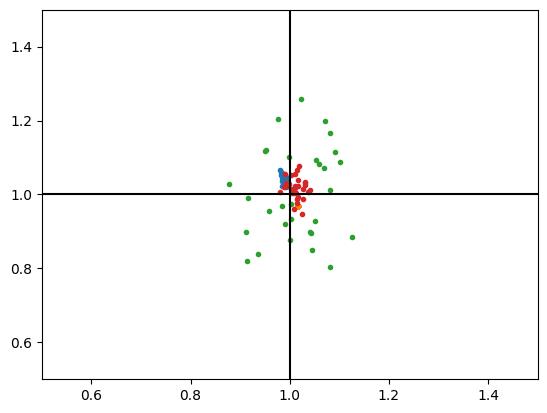

In [375]:
plt.plot(stats_eki['x_ens'][-1][0], stats_eki['x_ens'][-1][-1], '.')
#plt.plot(stats_eki_rl['x_ens'][-1][0], stats_eki_rl['x_ens'][-1][-1], '.')
plt.plot(stats_eki_30['x_ens'][-1][0], stats_eki_30['x_ens'][-1][-1], '.')
#plt.plot(stats_eki_acc['x_ens'][-1][0], stats_eki_acc['x_ens'][-1][-1], '.')
plt.plot(stats_eki_loc['x_ens'][-1][0], stats_eki_loc['x_ens'][-1][-1], '.')
plt.plot(stats_eki_loc_acc['x_ens'][-1][0], stats_eki_loc_acc['x_ens'][-1][-1], '.')
#plt.plot(stats_eki_msf['x_ens'][-1][0], stats_eki_msf['x_ens'][-1][-1], '.')
#plt.plot(stats_eki_all['x_ens'][-1][0], stats_eki_all['x_ens'][-1][-1], '.')
#plt.plot(stats_eki_all['x_ens'][-1][0], stats_eki_all['x_ens'][-1][-1], '.')

plt.axhline(y=1, color='k')
plt.axvline(x=1, color='k')
plt.ylim([0.5,1.5])
plt.xlim([0.5,1.5])

In [190]:
class fun3D:
    '''
    Linear overdetermined system in 3D:
    4 equations in 3 variables (x, y, z)
    True solution: x = 0.3, y = 0.4, z = 0.2
    '''
    def __init__(self, noise=0.0):
        self.calls = 0
        self.noise = noise

    def __call__(self, x):
        x = np.asarray(x)
        A = np.array([
            [1, 1, 1],
            [1, -1, 0],
            [2, 0, 1],
            [0, 1, -2],
        ])
        b = A @ np.array([0.3, 0.4, 0.2])  # Ensures known solution
        out = A @ x - b
        out += self.noise * np.random.randn(*out.shape)
        return out

    @cache
    def lookup_table(self, _x):
        self.calls += 1
        #print(f'Call: {self.calls}, accuracy: {np.linalg.norm(np.array([0.3, 0.4, 0.2]) - np.array(_x))}')
        return self(np.array(_x))

    def plot(self):
      plt.gca().scatter(0.3, 0.4, 0.2, color='b', s=50) 
fun3D()([0.3, 0.4, 0.2])

array([0., 0., 0., 0.])

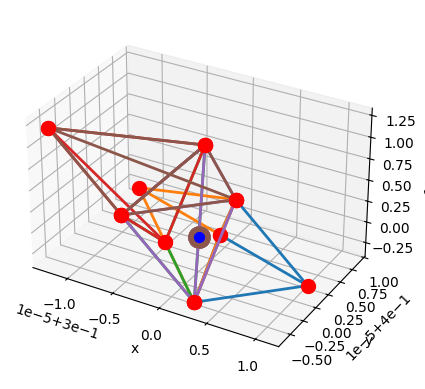

In [191]:
f = fun3D()
root, out = SimplexBisection(f, dimension=3, max_depth=50, bisect_parent=True);
plt.gcf().add_subplot(111, projection='3d')
root.plot_all(50)
fun3D().plot()

In [379]:
class fun3D_nonlinear:
    '''
    Nonlinear overdetermined system in 3D:
    6 equations in 3 variables (x, y, z)
    True solution: x = 0.3, y = 0.4, z = 0.2
    '''
    def __init__(self, noise=0.0, seed=0):
        self.calls = 0
        self.noise = noise
        self.errors = []
        self.dim_of_parameters = 3
        self.rng = np.random.default_rng(seed)

    def true_solution(self):
        return np.array([0.3, 0.4, 0.2])

    def __call__(self, x):
        x = np.asarray(x)
        self.calls += 1
        self.errors.append(np.linalg.norm(np.array(x)-np.array([0.3, 0.4, 0.2])))
        
        x0, x1, x2 = x
        x_true = self.true_solution()
        x0t, x1t, x2t = x_true

        # Define nonlinear system
        out = np.array([
            x0**2 + x1 + np.sin(x2) - (x0t**2 + x1t + np.sin(x2t)),
            x1**2 + x2 + np.sin(x0) - (x1t**2 + x2t + np.sin(x0t)),
            x2**2 + x0 + np.sin(x1) - (x2t**2 + x0t + np.sin(x1t)),
            x0 * x1 + x2**2 - (x0t * x1t + x2t**2),
            x1 * x2 + x0**2 - (x1t * x2t + x0t**2),
            x0 * x2 + x1**2 - (x0t * x2t + x1t**2),
        ])
        out += self.noise * self.rng.normal(size=out.shape)
        return out

    @cache
    def lookup_table(self, _x):
        return self(np.array(_x))

    def plot(self):
        x, y, z = self.true_solution()
        plt.gca().scatter(x, y, z, color='blue', s=60, label='True solution')
        plt.legend()

fun3D_nonlinear()([0.3, 0.4, 0.2])
#Simplex(dimension=3).is_x_inside([0.3, 0.4, 0.2])

array([0., 0., 0., 0., 0., 0.])

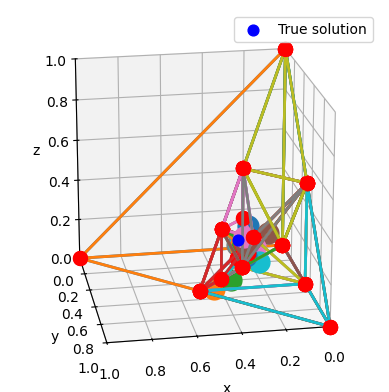

In [380]:
f_bisection = fun3D_nonlinear(noise=0.01, seed=1)
root, out = SimplexBisection(f_bisection, dimension=3, max_depth=10
                            , exploration=False, bisect_parent=True, evaluate_best=True);
plt.gcf().add_subplot(111, projection='3d')
root.plot_all(min_depth=0)
f_bisection.plot()
plt.gca().view_init(elev=20, azim=-1000)  # Adjust these values as you want

In [381]:
f_broyden = fun3D_nonlinear(noise=0.2, seed=0)
broyden_solver(f_broyden, np.zeros(3), niters=50)

array([0.35900205, 0.03447385, 0.43513542])

In [399]:
f_eki = fun3D_nonlinear(noise=0.2, seed=0)
EKI(f_eki, uniform=True, low=np.zeros(3), high=np.ones(3), ens_size=15, noise=0.2, niters=20, seed=0);

In [390]:
f_eki_rl = fun3D_nonlinear(noise=0.2, seed=0)
EKI(f_eki_rl, uniform=True, low=np.zeros(3), high=np.ones(3), ens_size=15, noise=0.2, randomized_likelihood=True, niters=20, seed=0);

In [397]:
f_eki_loc = fun3D_nonlinear(noise=0.2, seed=0)
EKI(f_eki_loc, y = np.zeros(6), uniform=True, low=np.zeros(3), high=np.ones(3), ens_size=15, noise=0.2, niters=20, seed=0,
   julia_backend=True, 
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()",);

In [401]:
f_eki_loc_acc = fun3D_nonlinear(noise=0.2, seed=0)
EKI(f_eki_loc_acc, y = np.zeros(6), uniform=True, low=np.zeros(3), high=np.ones(3), ens_size=15, noise=0.2, niters=20, seed=0,
   julia_backend=True, 
   localization_method = "EnsembleKalmanProcesses.Localizers.SECNice()",
   accelerator = "NesterovAccelerator()");

In [405]:
f_eki_msf = fun3D_nonlinear(noise=0.2, seed=0)
EKI(f_eki_msf, y = np.zeros(6), uniform=True, low=np.zeros(3), high=np.ones(3), ens_size=15, noise=0.2, niters=20, seed=0,
   julia_backend=True, 
   scheduler = "DataMisfitController(terminate_at = 1)",);